# **Evalution frameworks**

In [ ]:
!pip install matplotlib pandas scikit-learn seaborn

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#scikit-learn datasets & model selection
from sklearn.datasets import (make_classification, make_regression,load_breast_cancer,load_diabetes)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC

#regression models
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor

# Evalution metrics -
from sklearn.metrics import(
    accuracy_score, precision_score, recall_score,f1_score,confusion_matrix,ConfusionMatrixDisplay,roc_auc_score,roc_curve
,precision_recall_curve,classification_report,mean_absolute_error,mean_squared_error,r2_score)



plotting style

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
print("All libraries loaded successfully")
print(f"numpy:{np.__version__}| pandas:{pd.__version__}")

All libraries loaded successfully
numpy:2.0.2| pandas:2.2.2


Dataset Preparation

Classification:Breast Cancer dataset

In [ ]:
cancer=load_breast_cancer()
X_clf,y_clf=cancer.data,cancer.target
X_train_c,X_test_c,y_train_c,y_test_c=train_test_split(X_clf,y_clf,test_size=0.2,random_state=42)

#feature scaling
scaler=StandardScaler()
X_train_c=scaler.fit_transform(X_train_c)
X_test_c=scaler.transform(X_test_c)

# Diabaetes dataset
diabetes=load_diabetes()
X_reg,y_reg=diabetes.data,diabetes.target
X_train_r,X_test_r,y_train_r,y_test_r=train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

scaler=StandardScaler()
X_train_r=scaler.fit_transform(X_train_r)
X_test_r=scaler.transform(X_test_r)

#quick summary
print("CLASSIFICATION DATASET(BREAST CANCER)")
print(f" Train:{X_train_c.shape} | Test:{X_test_c.shape}")
print(f" class balance-malignant:{(y_clf==0).sum()} | benign:{(y_clf==1).sum()}")
print("REGRESSION DATASET(DIABETES)")
print(f" Train:{X_train_r.shape} | Test:{X_test_r.shape}")

print(f" Target range: [{y_reg.min():.0f},{y_reg.max():.0f}]")


CLASSIFICATION DATASET(BREAST CANCER)
 Train:(455, 30) | Test:(114, 30)
 class balance-malignant:212 | benign:357
REGRESSION DATASET(DIABETES)
 Train:(353, 10) | Test:(89, 10)
 Target range: [25,346]


In [ ]:
#first 5 features
print("Feature names:", cancer.feature_names[:5])

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness']


In [ ]:
# calculate imbalance ration(malignant/benign)
imbalance_ratio=(y_clf==0).sum()/(y_clf==1).sum()
print("Imbalance ratio:", imbalance_ratio)

Imbalance ratio: 0.5938375350140056


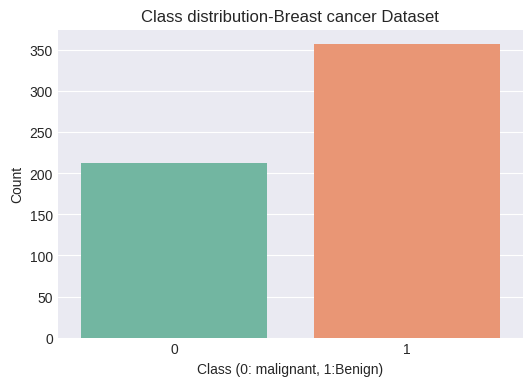

In [ ]:
#plot class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=y_clf,palette='Set2')
plt.title("Class distribution-Breast cancer Dataset")
plt.xlabel("Class (0: malignant, 1:Benign)")
plt.ylabel("Count")
plt.show()

Logistic Regression - Accuracy: 0.9737
Random Forest - Accuracy: 0.9649
Gradient Boosting - Accuracy: 0.9561


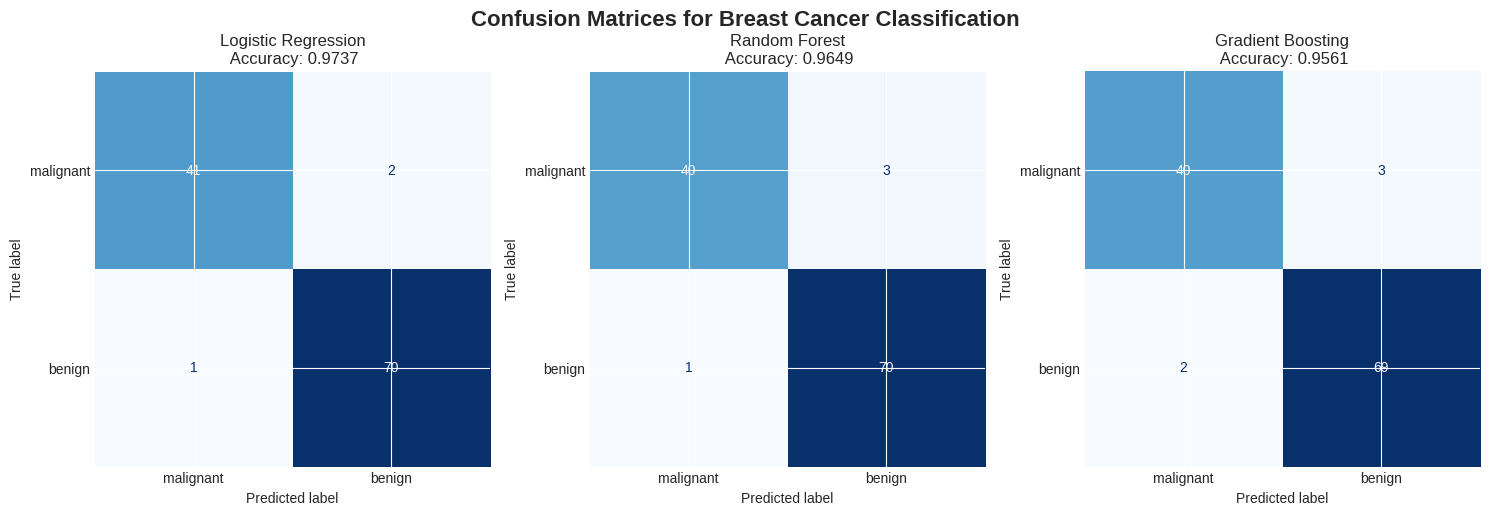

In [ ]:
#accuracy and confusion matrix
# Train three classifiers for comparison
models={
    'Logistic Regression':LogisticRegression(max_iter=1000),
    'Random Forest':RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting':GradientBoostingClassifier(n_estimators=100, random_state=42)
}

results={}

for name,model in models.items():
    model.fit(X_train_c,y_train_c)
    y_pred=model.predict(X_test_c)
    y_proba=model.predict_proba(X_test_c)[:,1]

    results[name]={
        'model':model,
        'y_pred':y_pred,
        'y_proba':y_proba,
        'accuracy':accuracy_score(y_test_c,y_pred),
        'cm':confusion_matrix(y_test_c,y_pred)}
    print(f"{name} - Accuracy: {results[name]['accuracy']:.4f}")

# visualize confusion matrices side by side
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, (name, result) in zip(axes, results.items()):
    disp = ConfusionMatrixDisplay(confusion_matrix=result['cm'], display_labels=cancer.target_names)
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f"{name}\n Accuracy: {result['accuracy']:.4f}", fontsize=12)

plt.tight_layout()
plt.suptitle("Confusion Matrices for Breast Cancer Classification",y=1.02,fontweight='bold',fontsize=16)
plt.show()

confusion matrix

In [ ]:
print(results['Logistic Regression']['cm'])

[[41  2]
 [ 1 70]]


In [ ]:
log_reg_cm = results['Logistic Regression']['cm']
TN_lr = log_reg_cm[0][0]
FP_lr = log_reg_cm[0][1]
FN_lr = log_reg_cm[1][0]
TP_lr = log_reg_cm[1][1]

print("Logistic Regression - True Positives (TP):", TP_lr)
print("Logistic Regression - True Negatives (TN):", TN_lr)
print(
    "Logistic Regression - False Positives (FP):",
    FP_lr,
)
print(
    "Logistic Regression - False Negatives (FN):",
    FN_lr,
)

Logistic Regression - True Positives (TP): 70
Logistic Regression - True Negatives (TN): 41
Logistic Regression - False Positives (FP): 2
Logistic Regression - False Negatives (FN): 1


In [ ]:
manual_accuracy_lr = (TP_lr + TN_lr) / (TP_lr + TN_lr + FP_lr + FN_lr)
sklearn_accuracy_lr = results['Logistic Regression']['accuracy']

print(f"Logistic Regression - Manual Accuracy: {manual_accuracy_lr:.4f}")
print(f"Logistic Regression - Scikit-learn Accuracy: {sklearn_accuracy_lr:.4f}")

Logistic Regression - Manual Accuracy: 0.9737
Logistic Regression - Scikit-learn Accuracy: 0.9737
